<a id="contents"></a><br>
# Contents
[R working environment](#setup)  
[Data cleaning](#clean)  
1. [Calculate PCR efficiencies and correct Ct values](#PCReff)
2. [Interpolating missing or erroneous wΔCt values](#interolate)
3. [Relative Expression](#RE)

[NifH abundances as a function of moss, rock and proximity to fern rhizomes](#ecoNifH)

<a id="setup"></a> 
## R working environment

We have our reformated raw qPCR data in two CSVs, one with our dilution standards (`standards.csv`) and one with the Ct values, pure-water controls, etc. (`expMat.csv`). We'll use the R package `rtpcr` for estimates of PCR efficiency and for adjusting the Ct values of our target nifH and cyanobacterial 16S genes to a reference gene, the ribosomal RNA 16S gene. The repo and documentation for rtPCR is [here](https://github.com/mirzaghaderi/rtpcr), and the published paper is [here](https://doi.org/10.7717/peerj.20185).

In [94]:
library(rtpcr)
library(stats)
library(ggplot2)
library(lmerTest)

Loading required package: lme4

Loading required package: Matrix


Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step




In [33]:
qPCR <- read.csv("expMat.csv", row.names=1)
standards <- read.csv("standards.csv")

`qPCR` has all the raw data from our experiment, including predictor variables: rock type, moss type, location relative to fern rhizome ("location"), and observed threshold cycles for nifH, cyanobacterial 16S rRNA, and our reference gene:

In [34]:
head(qPCR)

,subsite,rock,moss,location,replicate,Ct_nifH,Ct_cyano16s,Ct_ref
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
B09,G01,G,DS,far,1,25.13721,16.26339,17.11365
D09,G05,G,DS,far,2,22.97042,13.55746,15.57098
F09,G22,G,DS,far,3,25.02060,18.57098,39.36213
H09,G23,G,DS,far,4,22.82162,13.37317,16.80852
A09,G01,G,DS,near,1,23.62055,14.69234,16.96503
C09,G05,G,DS,near,2,24.74349,16.62734,17.70571


General 16S was chosen as a reference gene, or "house-keeping" gene for two reasons. The first is that we know these systems are full of bacteria and that general abundance of microbes is going cause differences among samples in absolute abundance nitrogen-fixers and cyanobacteria. So just tracking absolute abundances of our genes is meaningless. We want find changes in cyanobacterial abundance and nitrogen-rixers relative to the total microbial population, as measured by general 16S levels.

The second, related reason is that both target genes are likely to amplify at some unknown level from plant tissue, due to organelle 16S and homologs of nifH. All qPCR template was diluted to the same concentration, so this erroneous amplification should at least be constant among samples. But presumably, the erroneous amplification is also present - and therefore subtracted out - by our reference gene, 16S.  

Concerning the standards curves, to compare the cycle thresholds of our different genes, we have to correct for different PCR efficiencies. Lisa extracted DNA from a pure culture of "<i>Anabaena variabilis</i>" (actually <i>Trichormus</i>), and diluted to concentrations of 1%, 2%, 4%, 8%, 16%, 32%, 64%, 100%.

In [35]:
print(standards)

  dilutions general16S  cyano16S      nifH
1      0.01   28.49027 18.246068 19.921861
2      0.02   18.18309 24.275106 18.548350
3      0.04   29.30296 23.297349 17.465331
4      0.08   16.06012 15.460013 27.650442
5      0.16   14.40573 27.666826 15.211600
6      0.32   12.81892 11.151339 12.003414
7      0.64   10.74349  9.831721  8.073983
8      1.00   14.93850  8.444182 14.558652


<a id=clean></a>
## Data cleaning

<a id=PCReff></a>
### Calculate PCR efficiencies and correct Ct values 

In [36]:
eff <- efficiency(standards)

$Efficiency
        Gene     Slope        R2        E
1 general16S -7.584238 0.6015711 1.354729
2   cyano16S -6.655762 0.4317308 1.413337
3       nifH -4.914745 0.3650430 1.597605

$Slope_compare
$emtrends
 variable   log10(dilutions).trend   SE df lower.CL upper.CL
 general16S                  -7.58 2.77 18    -13.4   -1.758
 cyano16S                    -6.66 2.77 18    -12.5   -0.830
 nifH                        -4.91 2.77 18    -10.7    0.911

Confidence level used: 0.95 

$contrasts
 contrast              estimate   SE df t.ratio p.value
 general16S - cyano16S   -0.928 3.92 18  -0.237  0.9696
 general16S - nifH       -2.669 3.92 18  -0.681  0.7775
 cyano16S - nifH         -1.741 3.92 18  -0.444  0.8977

P value adjustment: tukey method for comparing a family of 3 estimates 


$plot


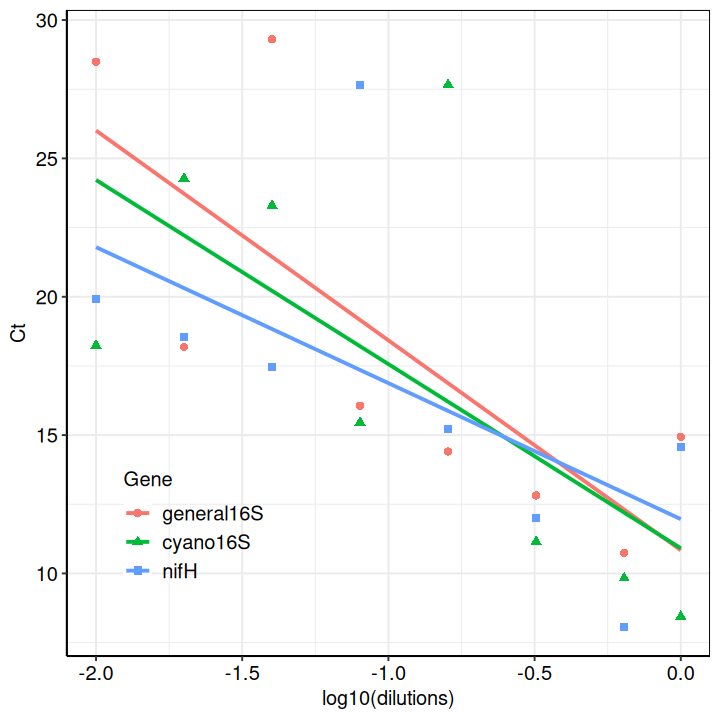

In [37]:
eff

There is a lot of noise in these, and the final efficiences are far from great (perfect would be 2.0). But the general correlation of decreasing concentration with increasing cycle number is correct in all genes, at least. And the nifH amplification is quite predictable, even if low. 

We add these efficiencies to our data:

In [38]:
qPCR['nifH'] <- eff$Efficiency[eff$Efficiency$Gene == 'nifH',"E"]
qPCR['cyano16s'] <- eff$Efficiency[eff$Efficiency$Gene == 'cyano16S',"E"]
qPCR['ref'] <- eff$Efficiency[eff$Efficiency$Gene == 'general16S',"E"]

We need to adjust our raw Ct values for nifH and cyano16s using our reference 16s Ct values. Since we have different PCR effeciencies, and low efficiencies, we use the generalized method for weighting our Ct values, which takes into account both the Ct values of the reference gene, and the different PCR efficiencies of both the target and reference genes. Details are [here](https://github.com/mirzaghaderi/rtpcr/blob/main/Method.md) and [here](https://doi.org/10.1186/s12859-017-1949-5). 

Using the rtpcr package, this has to be done one gene at a time:


In [39]:
nifHonly <- qPCR[, c("rock","moss","location","replicate","nifH","Ct_nifH","ref","Ct_ref")]
qPCR['nifH_wDCt'] <- compute_wDCt(
                       x=nifHonly,
                       block=NULL,
                       numOfFactors=3,
                       numberOfrefGenes=1, 
                       set_missing_target_Ct_to_40 = TRUE
                           )['wDCt']

In [40]:
cyano16Sonly <- qPCR[, c("rock","moss","location","replicate","cyano16s","Ct_cyano16s","ref","Ct_ref")]
qPCR['cyano16s_wDCt'] <- compute_wDCt(
                       x=cyano16Sonly,
                       block=NULL,
                       numOfFactors=3,
                       numberOfrefGenes=1, 
                       set_missing_target_Ct_to_40 = TRUE
                           )['wDCt']

These weighted Ct values of the target genes are theoretically independent of the general abundance of microbial and plant organelle DNA in the sample. 

<a id=interolate></a>
### Interpolating missing or erroneous wΔCt values

There is only one problem with these "corrected" wDCt values of our target genes - their accuracy is entirely dependent on the presence of a successful reference gene PCR amplification and its measurement. If there is no accompanying general 16S Ct data, our raw Ct values from nifH and cyanobacterial 16S are worthless, they are thrown out. And if the measurement of the reference gene Ct is weird, it affects the accuracy of the corresponding target gene wDCt values. 

A good example is sample `F09`, which has extremely low "corrected" wDCT for nifH and cyanobacterial 16S, indicating really, really high abundance of these genes in this sample, compared to others: 

In [41]:
head(qPCR)

,subsite,rock,moss,location,replicate,Ct_nifH,Ct_cyano16s,Ct_ref,nifH,cyano16s,ref,nifH_wDCt,cyano16s_wDCt
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B09,G01,G,DS,far,1,25.13721,16.26339,17.11365,1.597605,1.413337,1.354729,9.4946594,0.62129883
D09,G05,G,DS,far,2,22.97042,13.55746,15.57098,1.597605,1.413337,1.354729,8.7057940,-0.05355216
F09,G22,G,DS,far,3,25.02060,18.57098,39.36213,1.597605,1.413337,1.354729,-0.3290866,-7.97190157
H09,G23,G,DS,far,4,22.82162,13.37317,16.80852,1.597605,1.413337,1.354729,8.0631711,-0.68757884
A09,G01,G,DS,near,1,23.62055,14.69234,16.96503,1.597605,1.413337,1.354729,8.5346287,-0.09772166
C09,G05,G,DS,near,2,24.74349,16.62734,17.70571,1.597605,1.413337,1.354729,8.9692127,0.54362649


We can plot this as a positive value, Relative Expression [(see below)](#), to get an idea of how far out these "corrected" values are from the others

In [42]:
options(repr.plot.width = 20, repr.plot.height = 6)

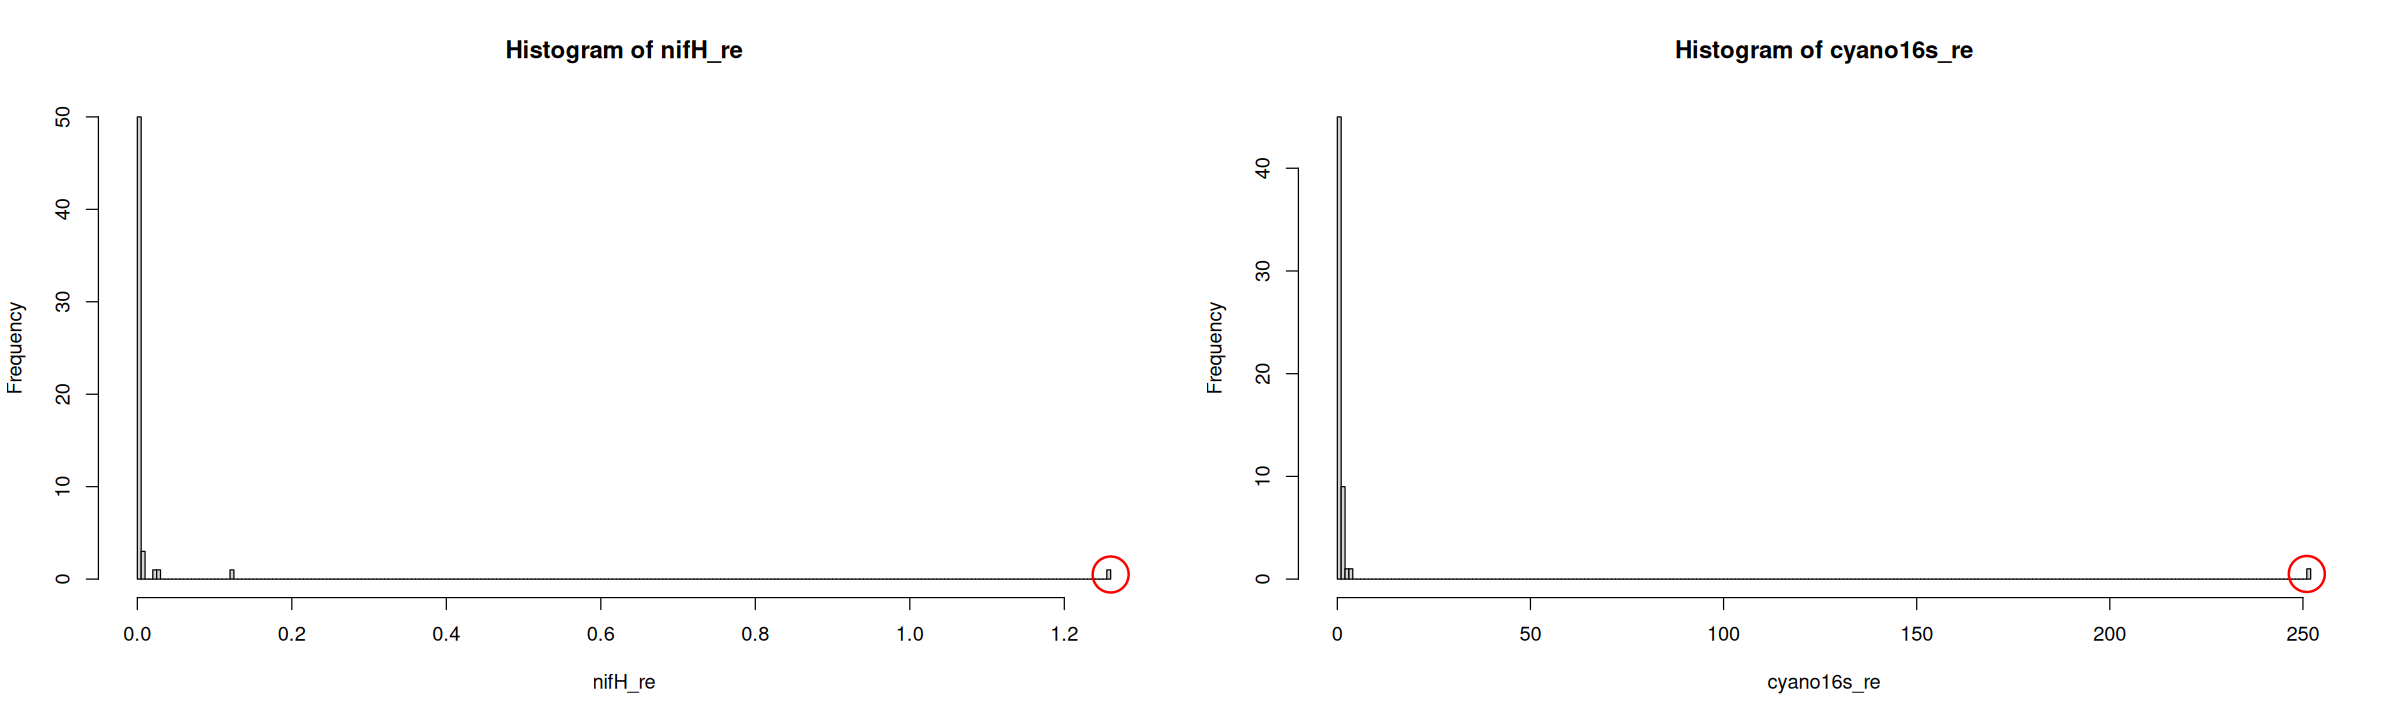

In [43]:
nifH_re <- 2^-(qPCR$nifH_wDCt)
cyano16s_re <- 2^-(qPCR$cyano16s_wDCt)

par(mfrow=c(1,2))
hist(nifH_re, breaks=300)
points(1.26,0.5, col="red", cex=4, lwd=2)
hist(cyano16s_re, breaks=300)
points(251,0.5, col="red", cex=4, lwd=2)

rm(nifH_re, cyano16s_re)


This is a clear outlier, in both the nifH and 16S abundances. The cause is an error in the reference gene used to weight this sample. Ct for our reference gene in this sample is 39.36, almost 40 cycles, meaning very low but non-zero abundance. The PCR reaction probably simply failed until late in the trial, when around 39 cycles amplification of contaminates probably began to appear. The Ct of the nifH and Cyanobacterial 16S are normal. So it's sort of like dividing by an incredibly small number, resulting in an astronomically, artificially high number.

In other cases, the 16S PCR simply failed to amplify at all. Given that our general 16S PCR amplifications had a high failure rate (20 reactions failed out of 76,  or 26% of our samples), we lose a lot of statistical power from this. 

But we just generated a lot of wDCt data, we can make a model now from our raw Ct values in each gene, and use it to interpolate the final wDCt in cases where we have inaccurate or missing reference gene Ct data, but good nifH or cyanobacterial 16S observations.  

In [58]:
## start with nifH 

## get rid of the outlier noticed above
qPCR_noOut <- qPCR[rownames(qPCR) != "F09",]

## make a model of wDCt from raw Ct
nifHfit <- lm(nifH_wDCt ~ Ct_nifH, data=qPCR_noOut)
## make some predictions of using our original Ct values
qPCR['nifH_wDCt_predicted'] <- predict(nifHfit, newdata=qPCR["Ct_nifH"]) 
## find the places where general 16S failed or gave unreliable results:
badGeneral16sRows <- rownames(qPCR[is.na(qPCR$Ct_ref) | qPCR$Ct_ref > 35,])

## make a new column, based on the experimental values, but plugging 
## interpolated values predicted from raw nifH_ct scores and
## our model in where necessary

## now with the ugliest old school R code possible, 
## plug in interpolated values
nifH_wDCt_interp <- qPCR['nifH_wDCt']
for (i in badGeneral16sRows){
  nifH_wDCt_interp[i,'nifH_wDCt'] <- qPCR[i,"nifH_wDCt_predicted"]
}

## add back into our data matrix
qPCR["nifH_wDCt_interp"] <- nifH_wDCt_interp['nifH_wDCt'] 

In [74]:
options(repr.plot.width = 20, repr.plot.height = 10)

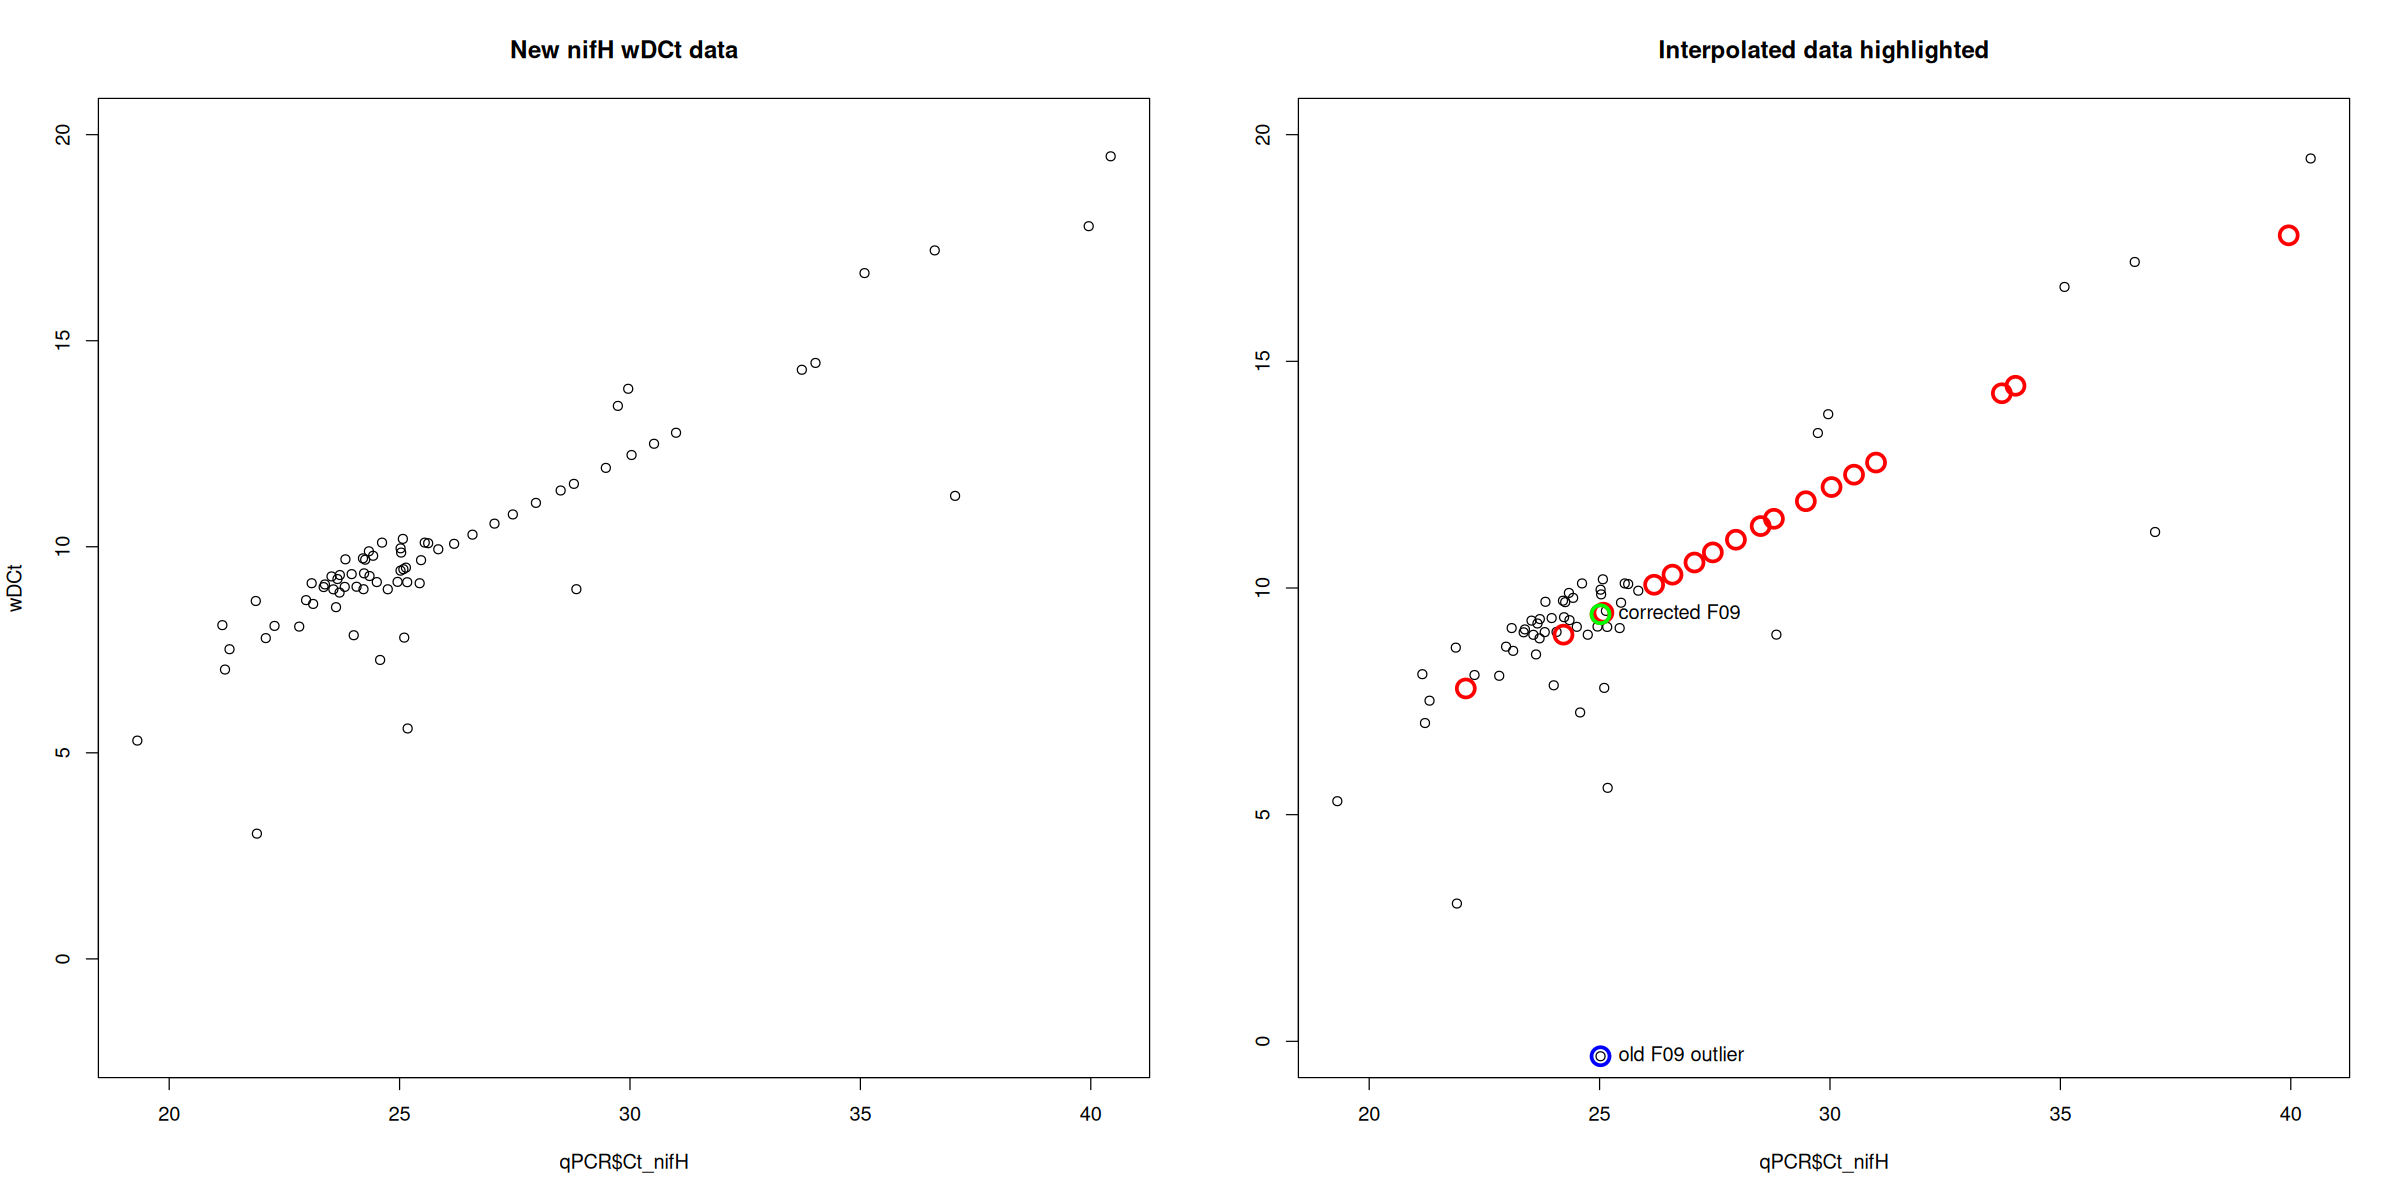

In [77]:
par(mfrow=c(1,2))
plot(qPCR$nifH_wDCt_interp ~ qPCR$Ct_nifH, main="New nifH wDCt data", ylab="wDCt", ylim=c(-2,20))
plot(qPCR$nifH_wDCt ~ qPCR$Ct_nifH, main="Interpolated data highlighted", ylab="",ylim=c(0,20))
#abline(lm(qPCR_noOut$nifH_wDCt ~ qPCR_noOut$Ct_nifH), lty=3)
points(x=qPCR[badGeneral16sRows,"Ct_nifH"],
       y=qPCR[badGeneral16sRows,"nifH_wDCt_interp"],
       col="red",
       cex=2,
       lwd=3,
       )
points(x=qPCR["F09","Ct_nifH"],
       y=qPCR["F09","nifH_wDCt_interp"],
       col="green",
       cex=2,
       lwd=3,
       )
text(x=qPCR["F09","Ct_nifH"],
       y=qPCR["F09","nifH_wDCt_interp"],
       pos="4",
       offset=0.75,
       labels="corrected F09"
       )
points(x=qPCR["F09","Ct_nifH"],
       y=qPCR["F09","nifH_wDCt"],
       col="blue",
       cex=2,
       lwd=3,
       )
text(x=qPCR["F09","Ct_nifH"],
       y=qPCR["F09","nifH_wDCt"],
       pos="4",
       offset=0.75,
       labels="old F09 outlier"
       )


These look like reasonable estimates of what the wΔCt should be from these raw Ct values. It is a tough decision, to interpolate or not, because they samples may have been different based on the behaviour of the housekeeping gene (general 16S) in these samples. Anyway, we will try using these values going forward. Repeat the process with cyanobacterial 16S genes.

In [71]:
qPCR_noOut <- qPCR[rownames(qPCR) != "F09",]

badGeneral16sRows <- rownames(qPCR[is.na(qPCR$Ct_ref) | qPCR$Ct_ref > 35,])
cyano16sfit <- lm(cyano16s_wDCt ~ Ct_cyano16s, data=qPCR_noOut)
qPCR['cyano16s_wDCt_predicted'] <- predict(cyano16sfit, newdata=qPCR["Ct_cyano16s"])

badGeneral16sRows <- rownames(qPCR[is.na(qPCR$Ct_ref) | qPCR$Ct_ref > 35,])

In [81]:
cyano16s_wDCt_interp <- qPCR['cyano16s_wDCt']
for (i in badGeneral16sRows){
  cyano16s_wDCt_interp[i,"cyano16s_wDCt"] <- qPCR[i,"cyano16s_wDCt_predicted"]
}
qPCR["cyano16s_wDCt_interp"] <- cyano16s_wDCt_interp ## add to our data matrix

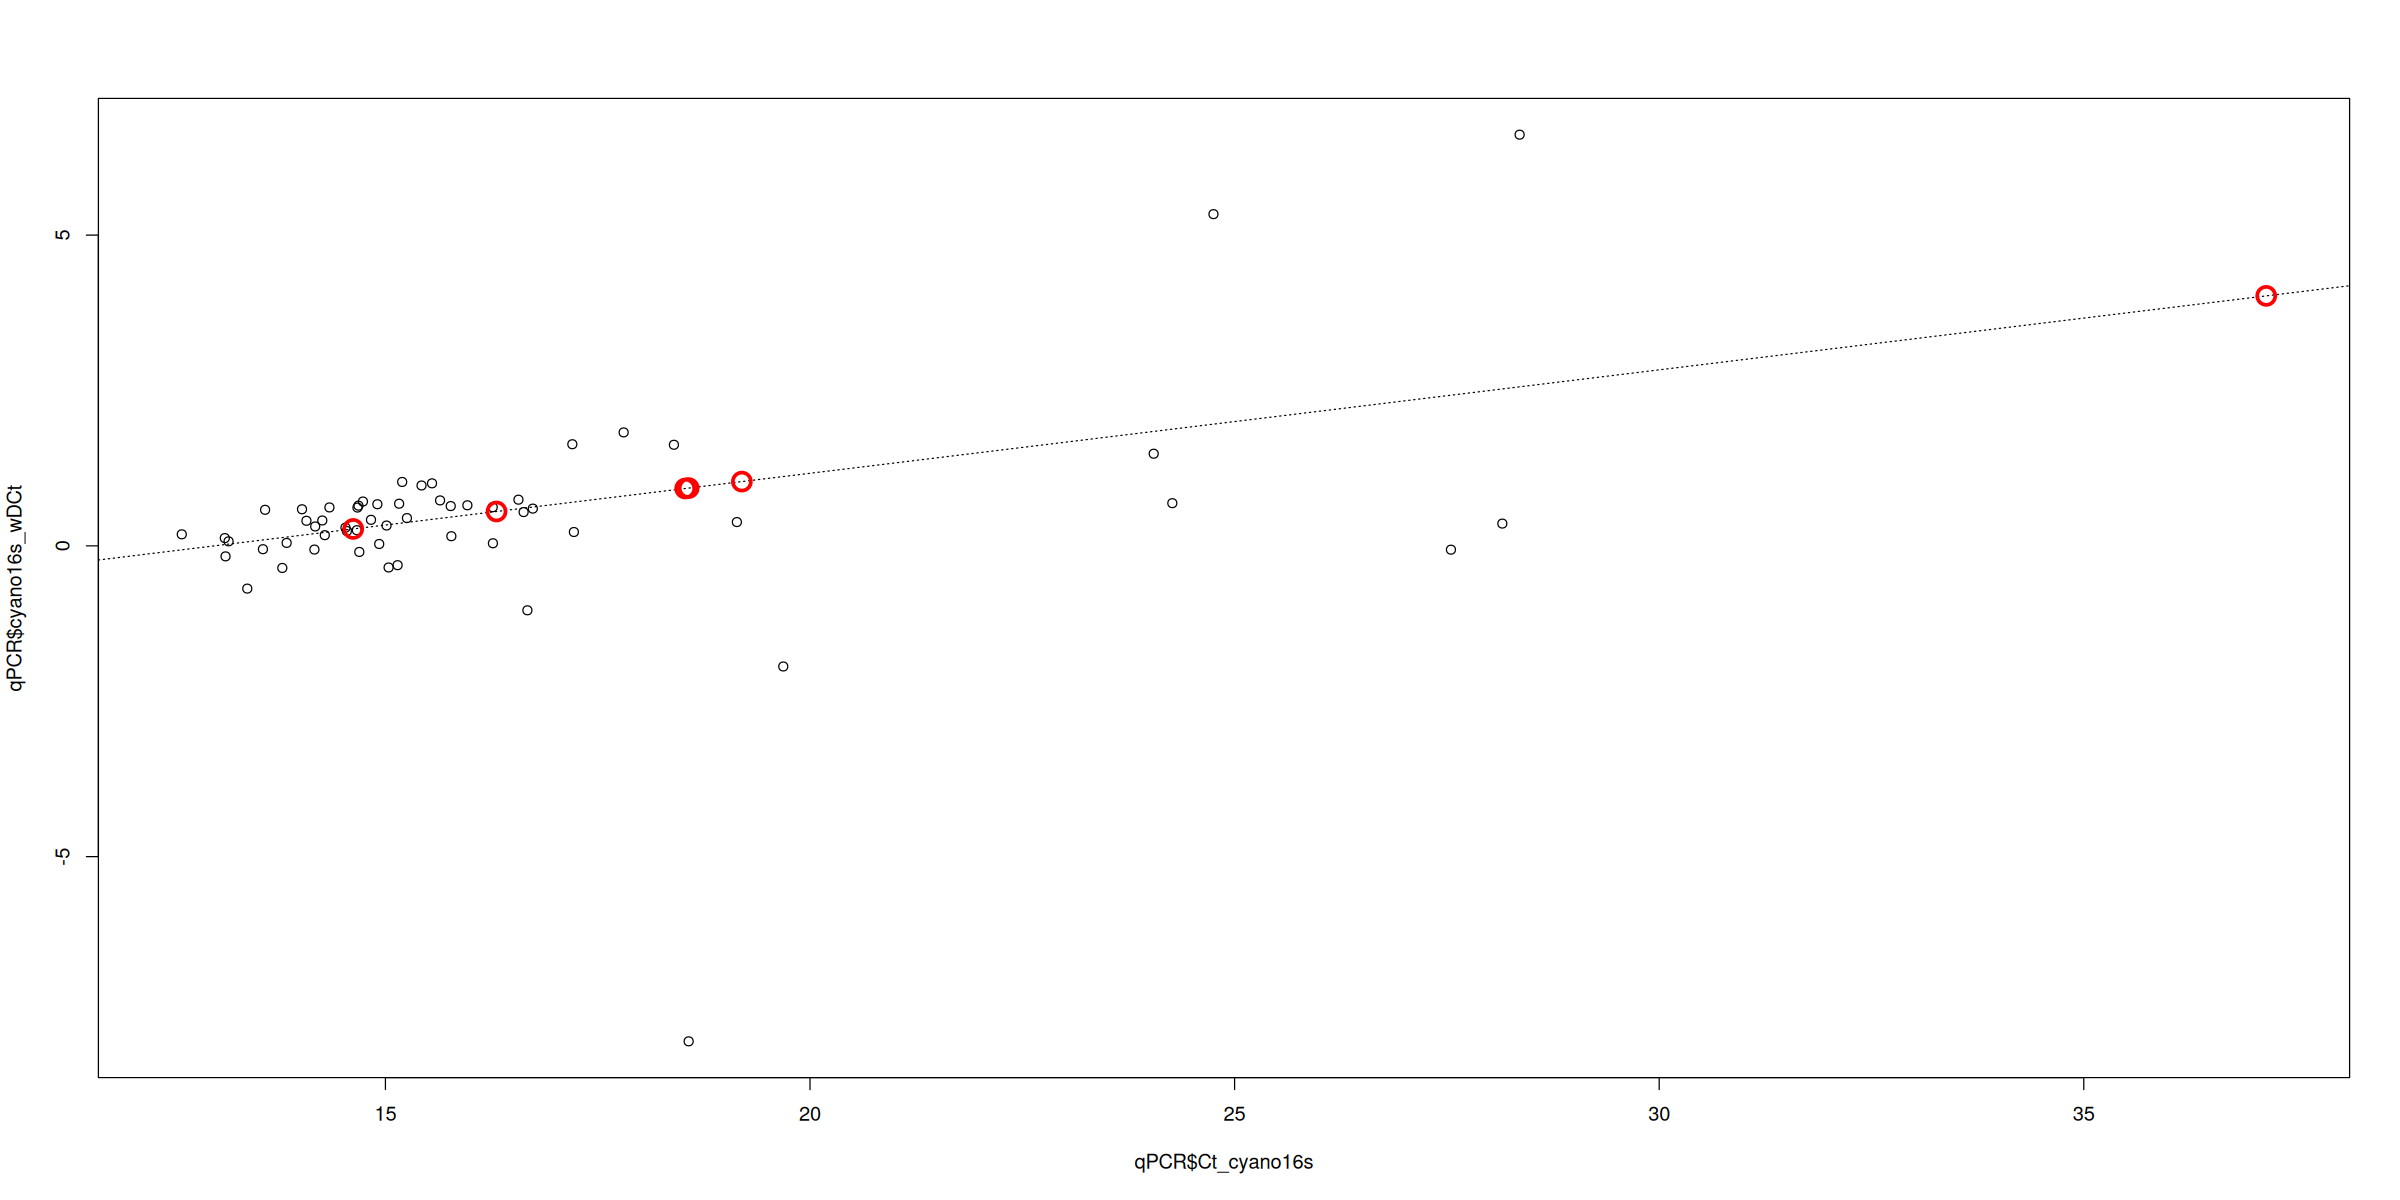

In [83]:
plot(qPCR$cyano16s_wDCt ~ qPCR$Ct_cyano16s)
abline(lm(qPCR_noOut$cyano16s_wDCt ~ qPCR_noOut$Ct_cyano16s), lty=3)
points(x=qPCR[badGeneral16sRows,"Ct_cyano16s"],
       y=qPCR[badGeneral16sRows,"cyano16s_wDCt_interp"],
       col="red",
       cex=2,
       lwd=3,
       )


Looks reasonable. We don't recover as much data as we did with nifH above, but this is because cyanobacterial qPCR reactions also failed at a high rate (14 reactions out of 76, 18%). 

<a id=RE></a>
### Relative Expression

These modified Ct values, now called wDCt, can be used to back-calculate to "relative expression", which is a unit-less value that showed be directly (linearly) related to how many copies of the target gene were originally present in the DNA in each sample, but independent of the patterns of general abundance of microbial and plant organelle DNA in the sample. The calculation is really simple:

In [84]:
qPCR["nifH_RE"] <- 2^-(qPCR["nifH_wDCt_interp"])

qPCR['cyano16s_RE'] <- 2^-(qPCR["cyano16s_wDCt_interp"])

We can remove the abundances of nifH and cyanobacterial 16S that were observed in our pure-water control samples, as anything in these was just noise or lab contamination:

In [85]:
## get the larger RE of our two water-only samples
nifH_RE_control <- max(qPCR[qPCR$subsite=="NTC","nifH_RE"])
## subtract all RE values by this
qPCR["nifH_RE_corrected"] <- qPCR["nifH_RE"] - nifH_RE_control
## set negatives equal to zero.
qPCR$nifH_RE_corrected[qPCR$nifH_RE_corrected < 0] <- 0

In [86]:
## cyano16s
cyano16s_RE_control <- max(qPCR[qPCR$subsite=="NTC",'cyano16s_RE'] )
qPCR["cyano16s_RE_corrected"] <- qPCR["cyano16s_RE"] - cyano16s_RE_control
qPCR$cyano16s_RE_corrected[qPCR$cyano16s_RE_corrected < 0] <- 0

These REs should now be comparable among samples to ask some ecological questions.

<a id=ecoNifH><a>
## NifH abundances as a function of moss, rock and proximity to fern rhizomes

<a id=nearFar></a>
### Proximity to fern rhizomes

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_boxplot()`).”


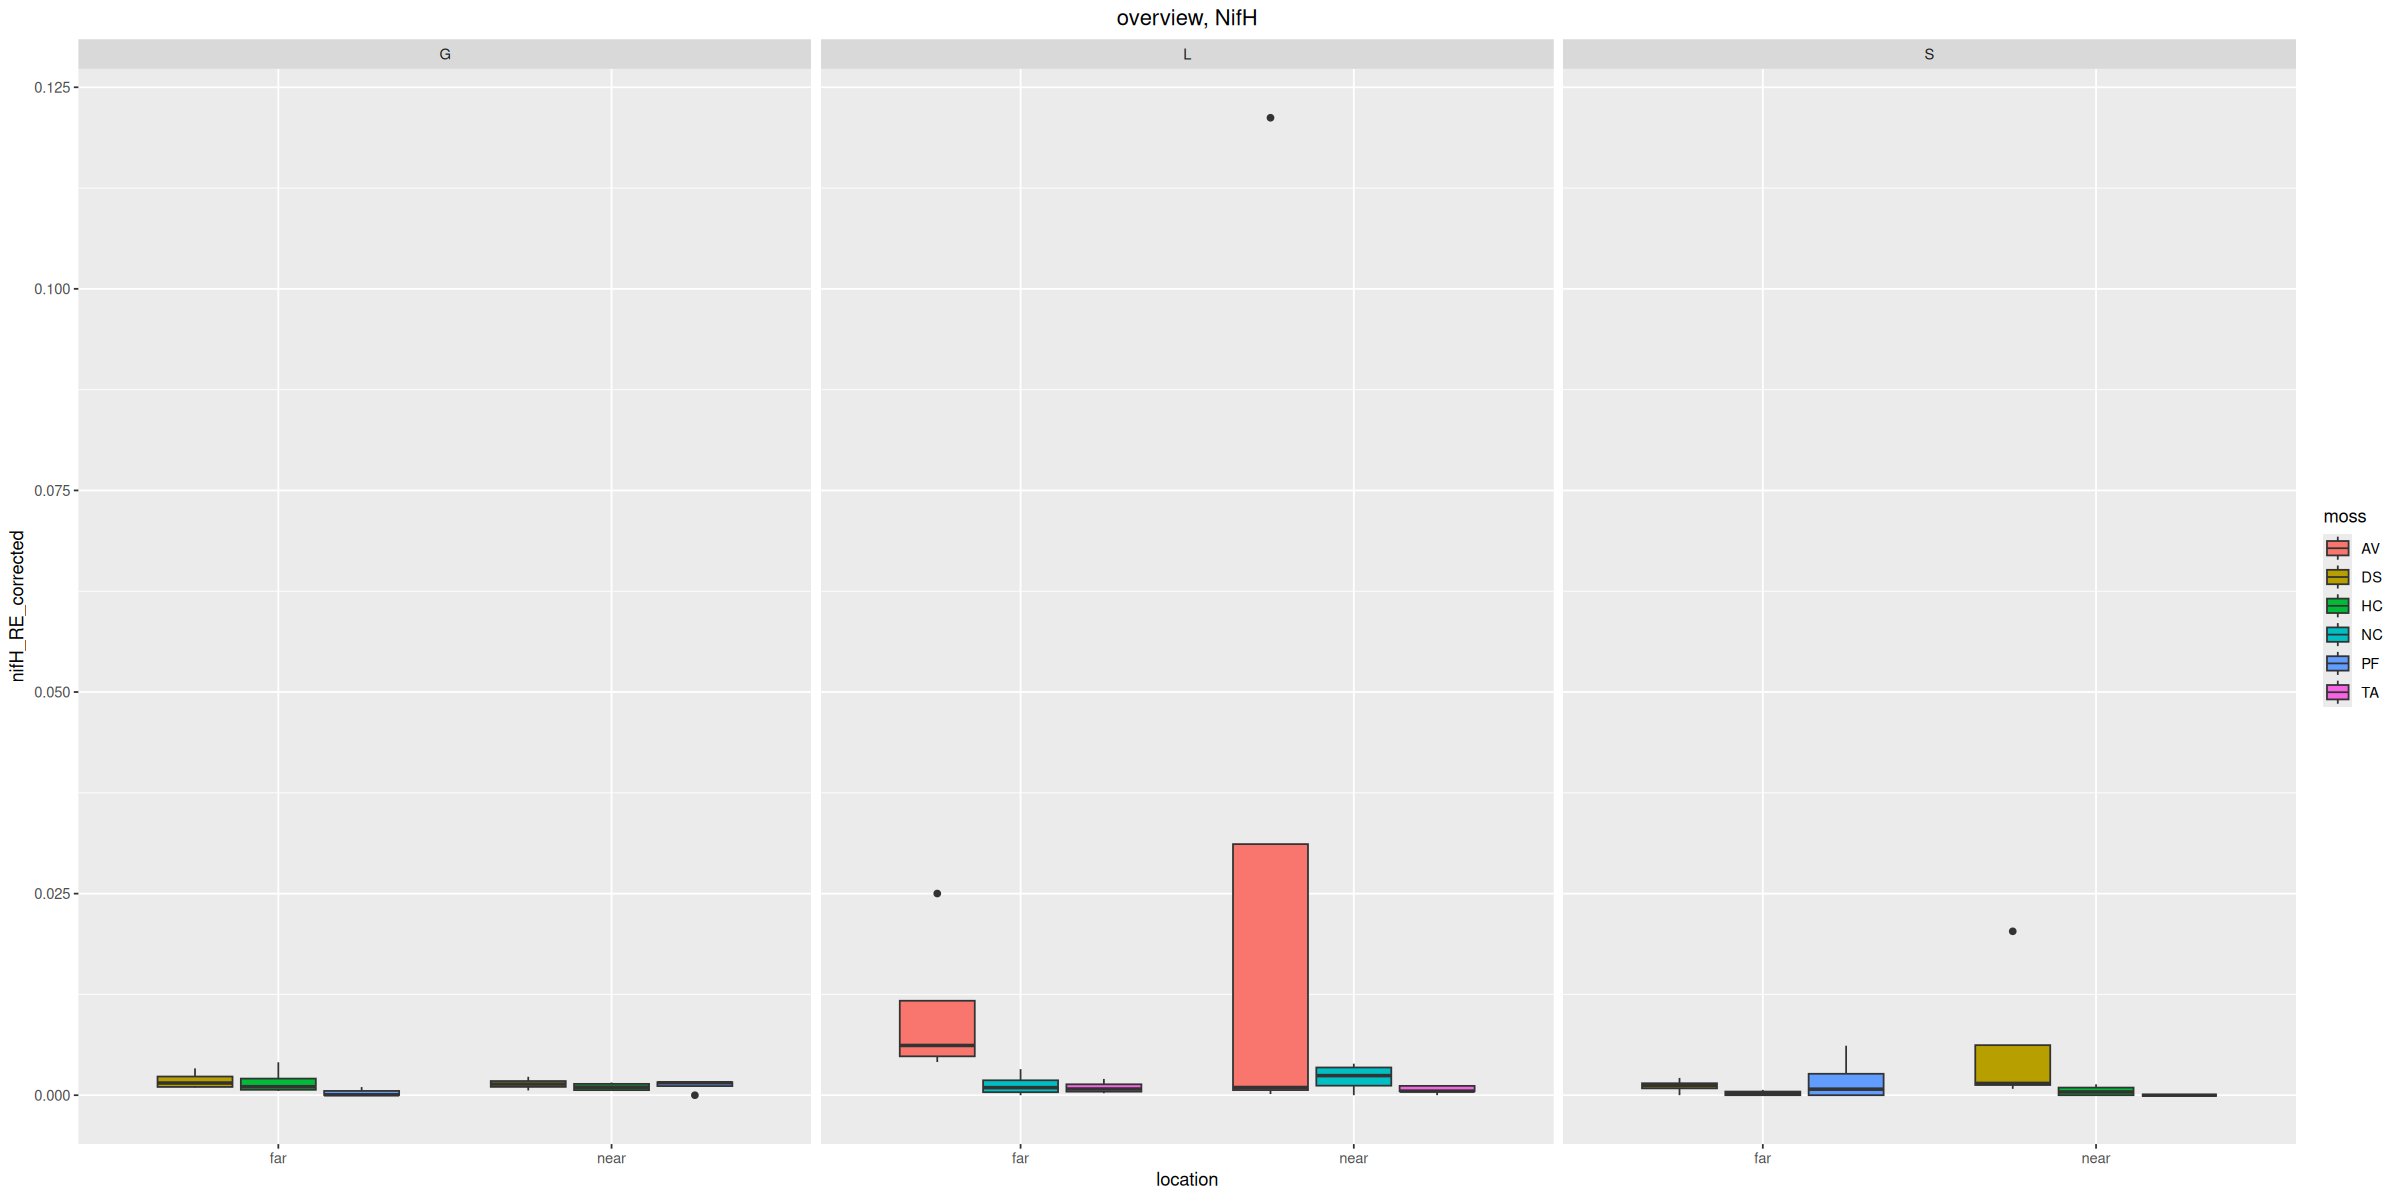

In [90]:
## remove controls
qPCRres <- qPCR[qPCR$subsite != "NTC", c("subsite","rock","moss","location","nifH_RE_corrected","cyano16s_RE_corrected")]

nifH_overview <- ggplot(qPCRres, aes(x=location, y=nifH_RE_corrected, fill=moss)) + 
                        geom_boxplot() + 
                        facet_grid(. ~ rock) +
                        ggtitle("overview, NifH") + 
                        theme(plot.title = element_text(hjust = 0.5))
nifH_overview 


Zoom in a little past the outliers:

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_boxplot()`).”


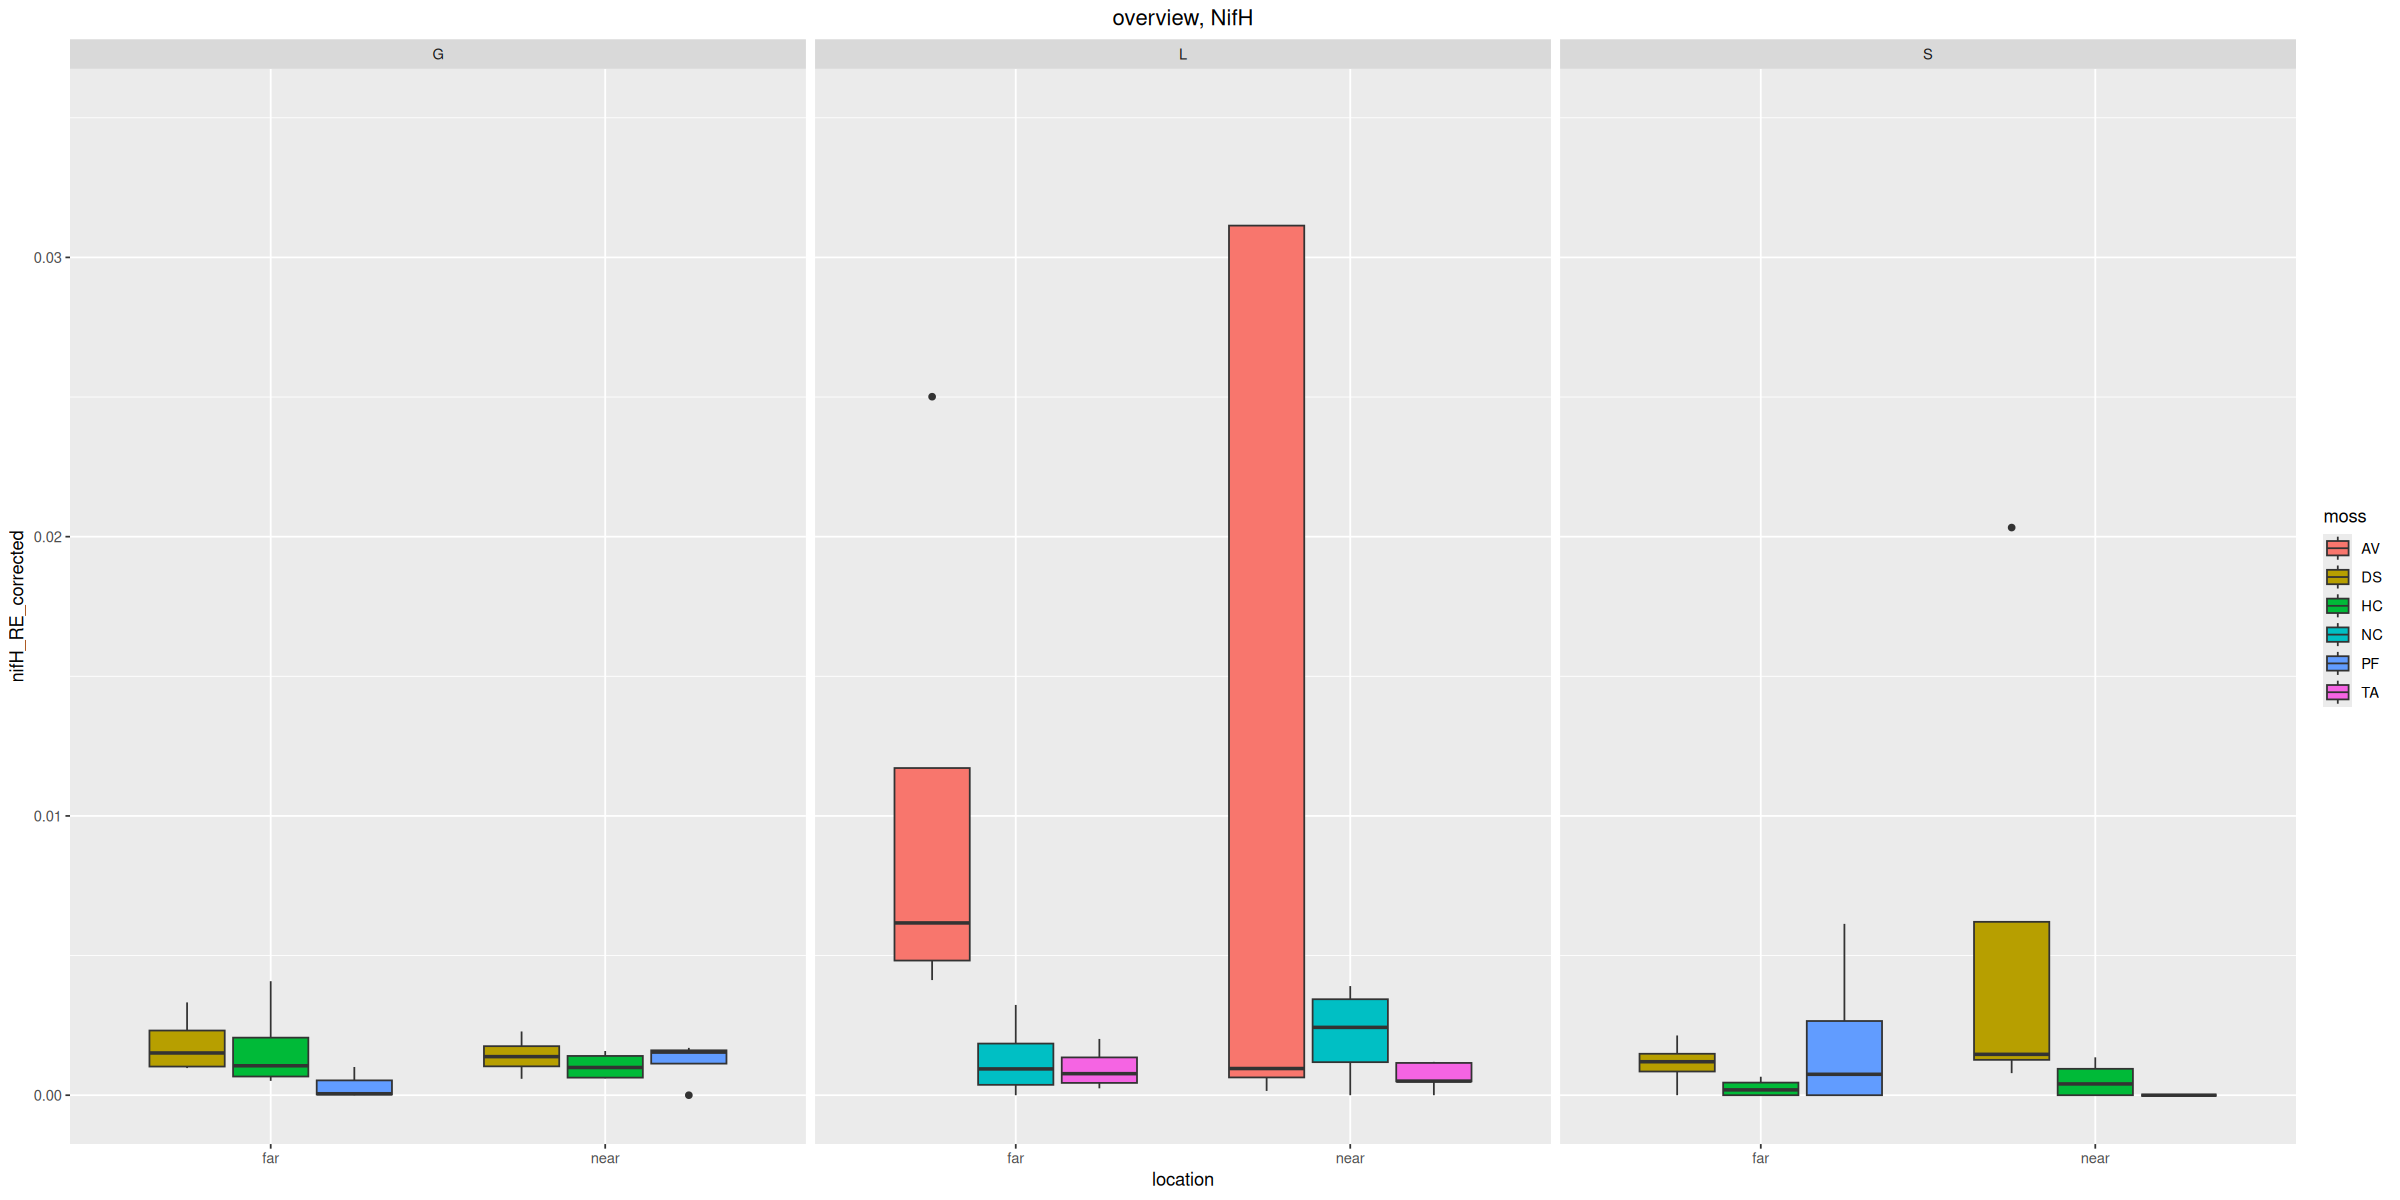

In [92]:
nifH_overview + coord_cartesian(ylim=c(0, .035))

I see no pattern, concerning proximity to fern rhizomes. But we can check with some models. Perhaps the first, simplest test is a paired t-test among all samples, regardless of rock type or moss type.

In [99]:
options(repr.plot.width =5, repr.plot.height = 5)


	Bartlett test of homogeneity of variances

data:  qPCRres$nifH_RE_corrected by qPCRres$location
Bartlett's K-squared = 61.943, df = 1, p-value = 3.536e-15


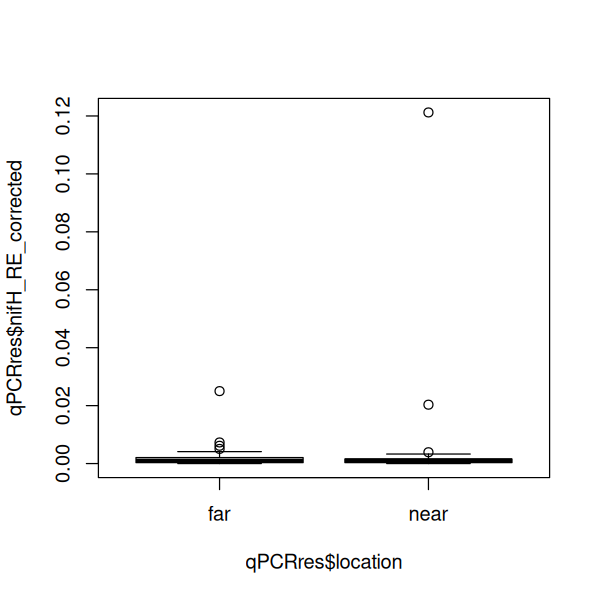

In [100]:
near_nifH_RE <- qPCRres[qPCRres$location == "near","nifH_RE_corrected"]
far_nifH_RE <- qPCRres[qPCRres$location == "far","nifH_RE_corrected"]
boxplot(qPCRres$nifH_RE_corrected ~ qPCRres$location) ## slighter higher RE in near samples
bartlett.test(qPCRres$nifH_RE_corrected ~ qPCRres$location)

Definitely different variances. But data are paired in near/far sets...

In [98]:
t.test(x=near_nifH_RE,y=far_nifH_RE,
       alternative = "greater",
       mu = 0, 
       paired = TRUE,
       var.equal = FALSE,
       conf.level = 0.95)


	Paired t-test

data:  near_nifH_RE and far_nifH_RE
t = 0.81097, df = 34, p-value = 0.2115
alternative hypothesis: true mean difference is greater than 0
95 percent confidence interval:
 -0.002990595          Inf
sample estimates:
mean difference 
    0.002756128 


Not significantly different. If we make a model that takes rock type or moss type into consideration? I don't think we can really do both, because some moss types only occurred on certain rock types. Makes for singularity. Much like my other hobbies.

Checking for near/far effect by moss:

In [101]:
summary(lmerTest::lmer(nifH_RE_corrected  ~ location  + (location|moss), data = qPCRres))

boundary (singular) fit: see help('isSingular')



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: nifH_RE_corrected ~ location + (location | moss)
   Data: qPCRres

REML criterion at convergence: -390.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.7387 -0.1324 -0.0708 -0.0183  7.3057 

Random effects:
 Groups   Name         Variance  Std.Dev. Corr 
 moss     (Intercept)  9.267e-06 0.003044      
          locationnear 4.532e-05 0.006732 1.00 
 Residual              1.792e-04 0.013386      
Number of obs: 72, groups:  moss, 6

Fixed effects:
             Estimate Std. Error       df t value Pr(>|t|)
(Intercept)  0.002579   0.002560 8.533627   1.008    0.341
locationnear 0.003488   0.004202 5.636349   0.830    0.440

Correlation of Fixed Effects:
            (Intr)
locationner -0.139
optimizer (nloptwrap) convergence code: 0 (OK)
boundary (singular) fit: see help('isSingular')


And rock type:

In [102]:
summary(lmerTest::lmer(nifH_RE_corrected  ~ location  + (location|rock), data = qPCRres))

boundary (singular) fit: see help('isSingular')

Warning message:
“Model failed to converge with 1 negative eigenvalue: -8.4e-01”


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: nifH_RE_corrected ~ location + (location | rock)
   Data: qPCRres

REML criterion at convergence: -386

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-0.4700 -0.2228 -0.1464 -0.0723  7.8841 

Random effects:
 Groups   Name         Variance  Std.Dev. Corr 
 rock     (Intercept)  0.000e+00 0.000000      
          locationnear 9.023e-06 0.003004  NaN 
 Residual              2.105e-04 0.014510      
Number of obs: 72, groups:  rock, 3

Fixed effects:
              Estimate Std. Error        df t value Pr(>|t|)
(Intercept)   0.002214   0.002418 67.675094   0.916    0.363
locationnear  0.002603   0.003836  4.414340   0.678    0.531

Correlation of Fixed Effects:
            (Intr)
locationner -0.630
optimizer (nloptwrap) convergence code: 0 (OK)
boundary (singular) fit: see help('isSingular')


Great, sampler didn't even converge. And both models are complaining about singularity. I don't know why, as near/far categories are evenly distributed across rock types and moss types. I don't want to take the time to fix this. There is no indication of a signal for this predictor (proximity to fern rhizome).